# 使用 k-均值聚类为电信用户分群


## 执行摘要

某电信运营商希望将其后付费用户群划分为若干行为分群，以便定向投放挽留优惠并合理调整流量套餐。本 notebook 先生成一份合成的用户使用量数据集，然后在 Base SAS 中运行一套完整的 k-均值分群流程：使用 **PROC STDIZE** 标准化各项使用驱动变量，通过 **PROC FASTCLUS** 比较不同候选 k 值下的伪 F 统计量来选定簇数，拟合一个按线路数 FREQ 加权的最终模型为每位用户评分，并导出学习得到的质心，以便下月快照无需重新聚类即可评分。最终得到的是一套可复用的分群方案，将原始使用量数据映射为可执行的挽留策略。


## 数据来源

**合成数据集：`WORK.SUBSCRIBERS`**（100 名后付费移动用户，通过 `call streaminit(20260531)` 在内联生成）

| 变量 | 类型 | 角色 | 说明 |
|----------|------|------|-------------|
| `cust_id` | Char | ID | 用户标识符（例如 `SUB000123`） |
| `tenure_months` | Num | 区间输入变量 | 线路在网时长（月），1-72 |
| `data_gb` | Num | 区间输入变量 | 月均移动数据使用量（GB） |
| `voice_min` | Num | 区间输入变量 | 月均通话分钟数 |
| `intl_min` | Num | 区间输入变量 | 月均国际通话分钟数 |
| `support_calls` | Num | 区间输入变量 | 近 90 天内的客服联系次数 |
| `monthly_charge` | Num | 区间输入变量 | 当前月账单金额（美元） |
| `plan_tier` | Char | 画像用途 | 套餐类型：`Basic`（基础版）、`Plus`（畅享版）或 `Unlimited`（无限量版） |
| `n_lines` | Num | FREQ 权重 | 账户下的线路数 |

生成器中内嵌了三种潜在行为画像——*轻度/价值型*、*重度数据/流媒体型*和*高接触/高流失风险型*——因此聚类分析有真实的结构可供还原。区间驱动变量输入 k-均值模型；`plan_tier` 被保留用于事后画像分析，`n_lines` 按账户线路数对每个账户进行加权。整个过程不使用任何外部文件或网络访问。


## 五步完成行为分群

移动运营商拥有数以百万计的后付费线路，一刀切的挽留策略会把预算浪费在本来就会留存的客户身上，却漏掉了即将流失的那些人。**行为分群**能把原始使用量数据转化为若干可执行的客户类型：对价格敏感的*轻度/价值型*用户、适合追加销售的*重度数据流媒体型*用户，以及需要主动关怀的*高接触/高流失风险*账户。

本 notebook 使用 `PROC FASTCLUS`（SAS 的 k-均值/不相交聚类过程）构建该分群方案。我们将：

1. 生成一份合成但贴近真实的用户使用量数据集。
2. 使用 **PROC STDIZE** 将各项使用驱动变量统一到同一尺度。
3. 通过比较不同候选 k 值下的伪 F 统计量来**选择簇数**。
4. 拟合一个 FREQ 加权的最终模型，为每位用户**评分**并对各分群进行画像分析。
5. **导出学习得到的质心**，以便模型可重新应用于下月快照。


## 步骤 1 - 生成合成用户样本

我们模拟 100 名后付费用户。每个用户都来自三种潜在画像之一，各自具有不同的使用特征，因此存在真实的簇结构可供还原。我们用 `call streaminit` 固定随机数流以保证可复现性，并用 `max`/`min`/`round` 将模拟值限制在合理范围内。

名义变量 `plan_tier`（套餐类型）与潜在画像相关（流媒体用户偏向*无限量版*；价值型用户偏向*基础版*），`n_lines`（线路数）稍后将作为 FREQ 权重，使多线路家庭账户按比例计入。


In [1]:
数据 subscribers;
    调用 streaminit(20260531);
    长度 cust_id $9 plan_tier $16;
    标签 cust_id          = "用户编号"
          tenure_months    = "在网时长（月）"
          data_gb          = "月均流量（GB）"
          voice_min        = "月均通话分钟数"
          intl_min         = "国际通话分钟数"
          support_calls    = "近90天客服次数"
          monthly_charge   = "月账单金额（美元）"
          plan_tier        = "套餐类型"
          n_lines          = "账户线路数";
    循环 i = 1 到 100;
        cust_id = cats('SUB', PUT(i, z6.));

        /* 三种潜在行为画像，占比不均 */
        u = rand('uniform');
        如果 u < 0.45 那么 profile = 1;        /* 轻度 / 价值型        */
        否则 如果 u < 0.80 那么 profile = 2;   /* 重度数据 / 流媒体型   */
        否则 profile = 3;                    /* 高接触 / 高流失风险   */

        如果 profile = 1 那么 循环;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        结束;
        否则 如果 profile = 2 那么 循环;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        结束;
        否则 循环;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        结束;

        /* 套餐类型与潜在画像相关 */
        p = rand('uniform');
        如果 profile = 1 那么
            plan_tier = ifc(p < 0.70, '基础版', ifc(p < 0.95, '畅享版', '无限量版'));
        否则 如果 profile = 2 那么
            plan_tier = ifc(p < 0.65, '无限量版', ifc(p < 0.90, '畅享版', '基础版'));
        否则
            plan_tier = ifc(p < 0.45, '畅享版', ifc(p < 0.80, '无限量版', '基础版'));

        /* 账户线路数：多数为单线 */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* 将金额 / 使用量四舍五入到合理精度 */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        输出;
    结束;
    删除 i u p profile;
运行;

过程 打印 数据=subscribers(obs=10) noobs 标签;
    标题 "合成用户使用记录样本";
运行;


                                                       合成用户使用记录样本                                                       

        用户编号          套餐类型                在网时长（月）              月均流量（GB）                月均通话分钟数                国际通话分钟数              近90天客服次数                    月账单金额（美元）            账户线路数
SUB000001     基础版                              15                   9.7                    114                      5                    11                        57.07                2
SUB000002     基础版                              39                   0.6                    214                      2                     1                        35.88                3
SUB000003     无限量版                             45                  23.9                    325                      6                     1                       103.94                2
SUB000004     基础版                              41                   1.9                    202                      1                 


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## 步骤 2 - 将驱动变量统一到同一尺度

k-均值使用欧氏距离，如果直接对原始值聚类，像通话分钟数这样量级较大的变量会压过像客服次数这样量级较小的变量。标准做法是先把每个区间驱动变量标准化为均值 0、标准差 1。**PROC STDIZE** 配合 `METHOD=STD` 正是完成这一步，将标准化后的副本写入 `WORK.SUBS_STD`。我们让 `cust_id`、`plan_tier`、`n_lines` 原样保留，以便稍后用于加权和画像分析。


In [2]:
过程 stdize 数据=subscribers out=subs_std METHOD=std;
    变量 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
运行;

过程 均值 数据=subs_std mean std maxdec=3;
    变量 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    标签 tenure_months  = "在网时长（月）"
          data_gb        = "月均流量（GB）"
          voice_min      = "月均通话分钟数"
          intl_min       = "国际通话分钟数"
          support_calls  = "近90天客服次数"
          monthly_charge = "月账单金额（美元）";
    标题 "标准化驱动变量：均值≈0，标准差≈1";
运行;


                                                       合成用户使用记录样本                                                       

                                                   标准化驱动变量：均值≈0，标准差≈1                                                   

                                                  The MEANS Procedure

 Variable        Label                                 Mean     Std Dev
 ----------------------------------------------------------------------
 tenure_months   在网时长（月）                              0.000       1.000
 data_gb         月均流量（GB）                            -0.000       1.000
 voice_min       月均通话分钟数                             -0.000       1.000
 intl_min        国际通话分钟数                              0.000       1.000
 support_calls   近90天客服次数                            -0.000       1.000
 monthly_charge  月账单金额（美元）                            0.000       1.000
 ----------------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## 步骤 3 - 应分几群？比较候选 k 值下的伪 F 统计量

我们不去猜测簇数，而是对每个候选 k 值分别拟合 FASTCLUS，并读取其报告的模型拟合统计量。**伪 F 统计量**（簇间方差与簇内方差之比）与**总体 R 平方**都奖励更好的分离度；较好的 k 应使伪 F 较高，且再增加一个簇带来的收益递减。一个简短的宏循环以 `MAXITER=50` 与 `CONVERGE=0`（迭代至收敛）分别运行 k = 2、3、4。比较下面三份列表中的 `Pseudo F Statistic` 与 `Overall R-Squared` 行：内嵌结构本身有三种潜在画像，k = 3 给出的解最强、最均衡。


In [3]:
%macro pick_k;
    %循环 k = 2 %到 4;
        过程 FASTCLUS 数据=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            变量 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            标签 tenure_months  = "在网时长（月）"
                  data_gb        = "月均流量（GB）"
                  voice_min      = "月均通话分钟数"
                  intl_min       = "国际通话分钟数"
                  support_calls  = "近90天客服次数"
                  monthly_charge = "月账单金额（美元）";
            标题 "候选簇数：k = &k";
        运行;
    %结束;
%mend pick_k;
%pick_k;


                                                   标准化驱动变量：均值≈0，标准差≈1                                                   


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## 步骤 4 - 拟合最终分群模型并为每个用户评分

选定 k = 3 后，我们拟合生产用模型。此次运行完全遵循实际分群作业的惯用做法：

- `FREQ` 语句按 `n_lines`（线路数）对每个账户加权，因此在计算质心时，一个四线路的家庭账户贡献相当于单线路账户的四倍。
- `OUT=SCORED` 为每个用户写出其所属的 `CLUSTER`（簇编号）及其到该簇质心的 `DISTANCE`（距离）；`ID` 语句把 `cust_id` 带入该评分表。
- `MEAN=SEG_MEANS` 保存各簇的质心（标准化尺度）。
- `OUTSEED=SEG_SEEDS` 以 FASTCLUS 可再次读取的种子格式保存最终质心——这就是我们在步骤 6 中重新应用的导出模型。

模型拟合统计量已在步骤 3 的扫描中确定，因此这里加上 `SHORT` 选项，使列表聚焦于驱动评分输出的簇规模与质心。


In [4]:
过程 FASTCLUS 数据=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    变量 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    频率 n_lines;
    id cust_id;
    标签 tenure_months  = "在网时长（月）"
          data_gb        = "月均流量（GB）"
          voice_min      = "月均通话分钟数"
          intl_min       = "国际通话分钟数"
          support_calls  = "近90天客服次数"
          monthly_charge = "月账单金额（美元）"
          cust_id        = "用户编号"
          n_lines        = "账户线路数";
    标题 "最终分群：k = 3，按线路数 FREQ 加权";
运行;

过程 打印 数据=seg_means noobs 标签;
    标签 tenure_months  = "在网时长（月）"
          data_gb        = "月均流量（GB）"
          voice_min      = "月均通话分钟数"
          intl_min       = "国际通话分钟数"
          support_calls  = "近90天客服次数"
          monthly_charge = "月账单金额（美元）";
    标题 "分群质心（标准化尺度）";
运行;


                                                   标准化驱动变量：均值≈0，标准差≈1                                                   


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## 步骤 5 - 用业务单位刻画各分群画像

评分表中带有每位用户所属的 `CLUSTER`（簇）分配结果，但在标准化尺度上质心难以直观解读。为了把簇编号转化为业务画像，我们将分配结果关联回原始的 `subscribers` 表，并以真实单位——GB、分钟、美元——进行画像分析。PROC MEANS 按分群汇总各区间驱动变量，PROC FREQ 则将保留的 `plan_tier`（套餐类型）与分群交叉列表，展示每种画像的套餐构成。


                                                  分群画像：各簇平均使用情况（原始单位）                                                   

                                                  The MEANS Procedure

                               Analysis Variable : tenure_months 在网时长（月）

                                          N
                           簇编号          Obs      Mean      Std Dev      Minimum      Maximum
                           -----------------------------------------------------------------
                           1             51      33.2         14.7          1.0         61.0
                           2             31      40.5         14.0         17.0         67.0
                           3             18      12.7          7.1          1.0         30.0
                           -----------------------------------------------------------------

                                   Analysis Variable : data_gb 月均流量（GB）

                                          N
             


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


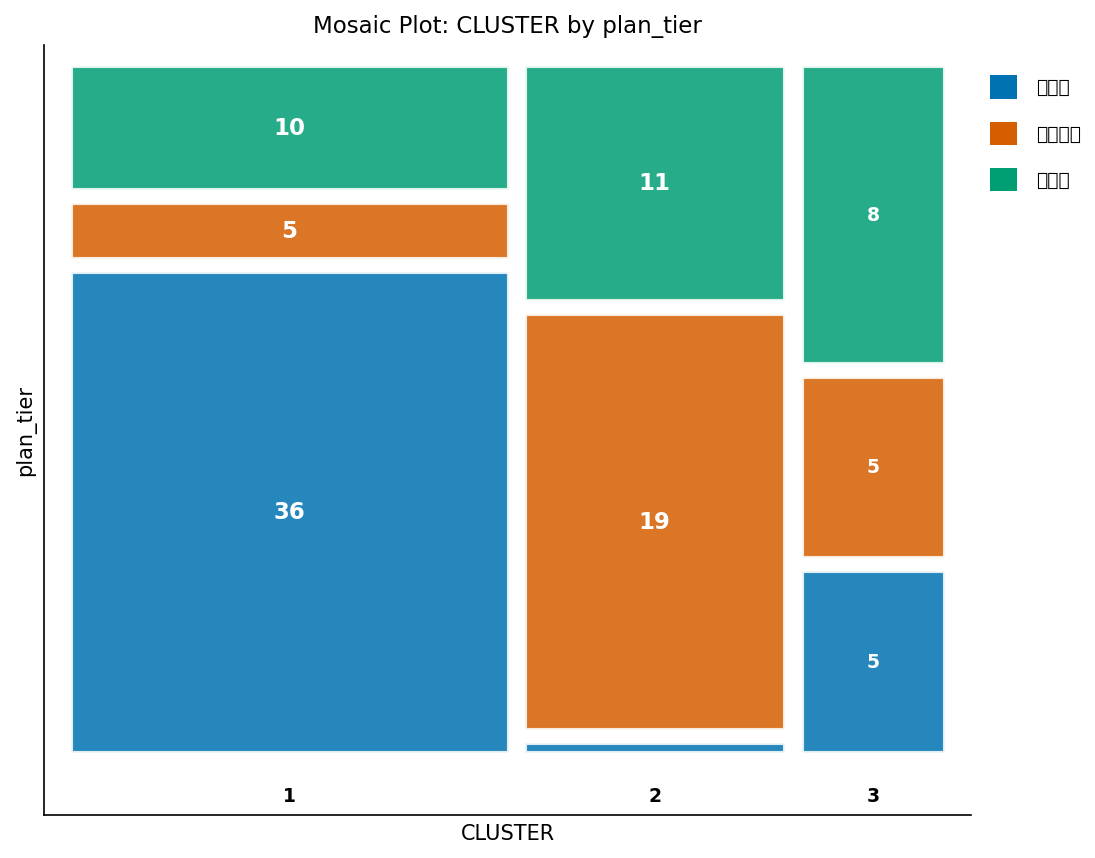

In [5]:
过程 排序 数据=scored out=scored_keys(保留=cust_id CLUSTER);
    按照 cust_id;
运行;

过程 排序 数据=subscribers out=subs_sorted;
    按照 cust_id;
运行;

数据 profile;
    合并 subs_sorted(IN=a) scored_keys(IN=b);
    按照 cust_id;
    如果 a 并且 b;
运行;

过程 均值 数据=profile mean std MIN MAX maxdec=1;
    分类 CLUSTER;
    变量 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    标签 CLUSTER        = "簇编号"
          tenure_months  = "在网时长（月）"
          data_gb        = "月均流量（GB）"
          voice_min      = "月均通话分钟数"
          intl_min       = "国际通话分钟数"
          support_calls  = "近90天客服次数"
          monthly_charge = "月账单金额（美元）";
    标题 "分群画像：各簇平均使用情况（原始单位）";
运行;

过程 频率 数据=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    标签 CLUSTER    = "簇编号"
          plan_tier  = "套餐类型";
    标题 "各分群的套餐类型构成";
运行;


## 步骤 6 - 将模型应用到下月快照

分群方案只有在无需重跑整个作业就能重新应用时才真正有用。我们在步骤 4 中保存到 `SEG_SEEDS` 的质心就是一个可移植的模型：把它以 `SEED=SEG_SEEDS` 配合 `MAXITER=0` 传回，会让 FASTCLUS 只*分配*每个观测到其最近的已保存质心而不移动质心——这是纯粹的评分，而不是重新拟合。这里我们对同一份标准化快照重新评分，以确认导出的模型能重现原始分配结果；在生产环境中，你应改为让 `DATA=` 指向下月的标准化快照。


                                                       各分群的套餐类型构成                                                       


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


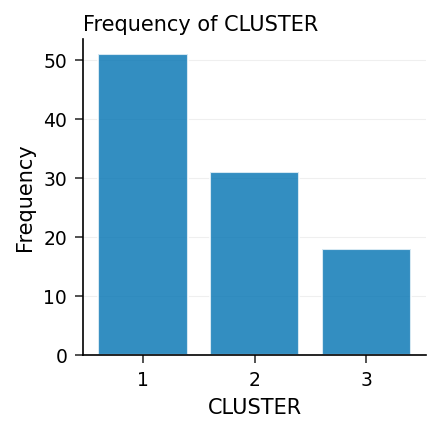

In [6]:
过程 FASTCLUS 数据=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    变量 tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    标签 tenure_months  = "在网时长（月）"
          data_gb        = "月均流量（GB）"
          voice_min      = "月均通话分钟数"
          intl_min       = "国际通话分钟数"
          support_calls  = "近90天客服次数"
          monthly_charge = "月账单金额（美元）"
          cust_id        = "用户编号";
    标题 "使用导出质心为新快照评分";
运行;

过程 频率 数据=rescored;
    TABLES CLUSTER / nocum;
    标签 CLUSTER = "簇编号";
    标题 "通过导出模型重新评分的用户";
运行;


## 解读结果

FASTCLUS 还原出了数据中内嵌的三种行为分群，画像分析表将其转化为一套挽留策略。请从上面的*分群画像*表中读取分群编号——簇标签是任意分配的，因此需要根据各自的使用特征来识别每种画像：

- **轻度 / 价值型用户** - 流量少、账单低、在网时长较长、客服联系极少，多数使用*基础版*套餐。这类客户稳定且对价格敏感；正确的做法是*保护利润*而非打折促销。合理的套餐推荐可以在不额外让利的前提下避免账单冲击。
- **重度数据流媒体用户** - 流量高、通话与国际通话分钟数高、账单为高端档位，多数使用*无限量版*套餐。他们忠诚且高价值：应采取*追加销售与设备升级*策略，并主动传达网络质量信息，防止竞争对手的促销把他们撬走。
- **高接触 / 高流失风险用户** - 在网时长短、客服联系量偏高、消费处于中等档位。频繁的客服联系加上较短的在网时长是典型的流失前兆。这是最应获得*主动挽留优惠*和服务补救跟进的分群。

使这一分析可靠的关键流程选择：**PROC STDIZE** 避免了量级较大的通话分钟数掩盖客服次数信号；伪 F 扫描为簇数选择提供了依据而非凭空猜测；`FREQ` 权重使多线路家庭账户按其规模比例计入；`OUTSEED=`/`SEED=` 的往返导出了质心，使市场团队只需一次 `MAXITER=0` 的 FASTCLUS 调用即可对每月快照重新分群——无需重新聚类。
